# Calibración de probabilidades — Riesgo de retraso en el pago

## Objetivo del notebook

El objetivo de este notebook es evaluar si las probabilidades producidas por la regresión logística seleccionada pueden interpretarse como estimaciones fiables del riesgo de retraso.

Hasta este punto se ha evaluado principalmente la capacidad del modelo para:

- discriminar entre facturas puntuales y tardías;
- ordenar correctamente las facturas según su nivel de riesgo;
- detectar una proporción elevada de retrasos.

El Modelo C seleccionado obtiene aproximadamente sobre validation:

- ROC-AUC = 0,904;
- PR-AUC = 0,802.

Estas métricas muestran una elevada capacidad de discriminación, pero no garantizan que las probabilidades estén correctamente calibradas.

Por ejemplo, si el modelo asigna una probabilidad cercana al 70 % a un grupo de facturas, un modelo bien calibrado debería observar aproximadamente un 70 % de retrasos reales dentro de ese grupo.

## Diferencia entre discriminación y calibración

La discriminación responde a preguntas como:

> ¿Las facturas que finalmente pagan tarde reciben mayor riesgo que las facturas puntuales?

Para ello se utilizan métricas como:

- ROC-AUC;
- PR-AUC.

La calibración responde a una pregunta diferente:

> Cuando el modelo predice una probabilidad del 60 %, ¿el evento ocurre aproximadamente el 60 % de las veces?

Un modelo puede presentar una discriminación elevada y, al mismo tiempo, probabilidades mal calibradas.

## Por qué es importante en este proyecto

La calibración resulta especialmente relevante porque el sistema pretende generar un scoring interpretable como:

`riesgo de retraso = 0.72`

Una probabilidad correctamente calibrada permitiría utilizar este valor no solo para ordenar facturas, sino también para:

- priorizar acciones de recobro;
- construir bandas de riesgo;
- estimar cobros esperados;
- integrar probabilidades en la futura simulación de tesorería.

## Metodología

Se mantendrán exactamente:

- las 34 features del Modelo C;
- el mismo split temporal;
- la misma regresión logística;
- el mismo pipeline de preprocesamiento.

En una primera fase se evaluará la calibración del modelo original sin modificarlo.

Se analizarán:

- calibration curve / reliability diagram;
- Brier Score;
- Log Loss;
- distribución de probabilidades.

Solo si existe evidencia de mala calibración se evaluarán métodos de calibración adicionales.

El conjunto de test continuará completamente reservado.

## Threshold

El threshold `0.40` seleccionado anteriormente debe considerarse provisional para las probabilidades originales de la regresión logística.

Si se modifica la calibración de las probabilidades, será necesario volver a estudiar el threshold, ya que la calibración puede cambiar la escala probabilística aunque el ranking de las observaciones se mantenga similar.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import sklearn

from sklearn.calibration import (
    calibration_curve,
)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [2]:
PROJECT_ROOT = Path("..")

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

GOLD_FILE = (
    GOLD_DIR
    / "gold_invoice_risk.parquet"
)

print(
    GOLD_FILE.resolve()
)

C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\gold\gold_invoice_risk.parquet


In [3]:
df = pd.read_parquet(
    GOLD_FILE
)

print(
    f"Filas: {df.shape[0]:,}"
)

print(
    f"Columnas: {df.shape[1]}"
)

display(
    df.head()
)

Filas: 2,466
Columnas: 48


,invoice_id,customer_id,invoice_date,due_date,invoice_amount,log_invoice_amount,paperless_bill,country_code,invoice_year,invoice_month,...,amount_diff_vs_previous_avg,open_amount_vs_current_invoice,overdue_amount_vs_current_invoice,is_new_customer,has_payment_history,has_3_payment_history,has_5_payment_history,has_open_invoices,has_overdue_invoices,late_payment
0,280670965,3993-QUNVJ,2012-01-03,2012-02-02,50.39,3.939444,PAPER,770,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0
1,5133177585,6708-DPYTF,2012-01-03,2012-02-02,55.37,4.031937,PAPER,391,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
2,5928070131,1604-LIFKX,2012-01-03,2012-02-02,97.60,4.591071,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
3,6050714721,8887-NCUZC,2012-01-03,2012-02-02,15.99,2.832625,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
4,6393629835,5164-VMYWJ,2012-01-03,2012-02-02,71.33,4.281239,PAPER,406,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0


## 1. Validación del dataset

La calibración se realizará sobre exactamente el mismo dataset Gold utilizado durante las fases anteriores.

Antes de reconstruir el modelo se comprobará que:

- existen 2.466 facturas;
- `invoice_id` continúa siendo único;
- existen 877 casos positivos;
- la variable objetivo no contiene valores ausentes;
- la tasa global de retraso permanece alrededor del 35,6 %.

El objetivo es garantizar que cualquier diferencia observada se debe exclusivamente al análisis de calibración y no a cambios en los datos.

### Checks

In [4]:
checks = pd.Series({
    "rows": len(df),

    "columns": df.shape[1],

    "duplicated_invoice_id": (
        df["invoice_id"]
        .duplicated()
        .sum()
    ),

    "missing_invoice_date": (
        df["invoice_date"]
        .isna()
        .sum()
    ),

    "missing_target": (
        df["late_payment"]
        .isna()
        .sum()
    ),

    "positive_cases": (
        df["late_payment"]
        .sum()
    ),

    "positive_rate_pct": (
        df["late_payment"]
        .mean()
        * 100
    ),
})

display(checks)

assert len(df) == 2466

assert df["invoice_id"].is_unique

assert df["invoice_date"].notna().all()

assert df["late_payment"].notna().all()

assert (
    df["late_payment"].sum()
    == 877
)

print(
    "✓ Dataset Gold validado."
)

rows                     2466.000000
columns                    48.000000
duplicated_invoice_id       0.000000
missing_invoice_date        0.000000
missing_target              0.000000
positive_cases            877.000000
positive_rate_pct          35.563666
dtype: float64

✓ Dataset Gold validado.


### Definir Modelo C

In [5]:
invoice_features = [
    "invoice_amount",
    "log_invoice_amount",
    "paperless_bill",
    "country_code",
]

temporal_features = [
    "invoice_year",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
    "is_month_start",
    "is_month_end",
    "days_since_dataset_start",
]

customer_history_features = [
    "previous_issued_count",
    "previous_avg_invoice_amount",
    "previous_median_invoice_amount",
    "days_since_previous_invoice",

    "previous_settled_count",
    "previous_late_count",
    "previous_late_rate",
    "previous_avg_delay",
    "previous_median_delay",
    "previous_max_delay",
    "last_payment_delay",
    "days_since_last_payment",

    "last_3_late_rate",
    "last_3_avg_delay",
    "last_5_late_rate",
    "last_5_avg_delay",

    "amount_vs_previous_avg",
    "amount_vs_previous_median",
    "amount_diff_vs_previous_avg",

    "is_new_customer",
    "has_payment_history",
    "has_3_payment_history",
    "has_5_payment_history",
]

model_features = (
    invoice_features
    + temporal_features
    + customer_history_features
)

assert len(model_features) == 34

print(
    f"Features Modelo C: "
    f"{len(model_features)}"
)

Features Modelo C: 34


### Variables categoricas y numericas

In [6]:
categorical_features = [
    "paperless_bill",
    "country_code",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
]

numeric_features = [
    col
    for col in model_features
    if col not in categorical_features
]

print(
    f"Numéricas: "
    f"{len(numeric_features)}"
)

print(
    f"Categóricas: "
    f"{len(categorical_features)}"
)

Numéricas: 29
Categóricas: 5


## 2. Reconstrucción del split temporal

Se utilizará exactamente la misma división temporal empleada durante baseline, interpretabilidad y comparación de modelos.

El objetivo es evaluar las probabilidades producidas por el mismo modelo en el mismo período de validation.

El conjunto de test se reconstruirá únicamente como parte de la estructura del proyecto, pero no será utilizado durante este notebook.

### Split temporal

In [7]:
unique_dates = np.sort(
    df["invoice_date"]
    .dropna()
    .unique()
)

train_cut_index = int(
    len(unique_dates) * 0.70
)

validation_cut_index = int(
    len(unique_dates) * 0.85
)

train_cutoff = (
    unique_dates[
        train_cut_index
    ]
)

validation_cutoff = (
    unique_dates[
        validation_cut_index
    ]
)

train_df = df[
    df["invoice_date"]
    < train_cutoff
].copy()

validation_df = df[
    (
        df["invoice_date"]
        >= train_cutoff
    )
    &
    (
        df["invoice_date"]
        < validation_cutoff
    )
].copy()

test_df = df[
    df["invoice_date"]
    >= validation_cutoff
].copy()

### Resumen split

In [8]:
split_summary = []

for name, subset in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():

    split_summary.append({
        "dataset": name,
        "rows": len(subset),

        "start_date": (
            subset["invoice_date"]
            .min()
        ),

        "end_date": (
            subset["invoice_date"]
            .max()
        ),

        "positive_cases": (
            subset["late_payment"]
            .sum()
        ),

        "positive_rate": (
            subset["late_payment"]
            .mean()
        ),
    })

split_summary = pd.DataFrame(
    split_summary
)

split_summary

,dataset,rows,start_date,end_date,positive_cases,positive_rate
0,train,1719,2012-01-03,2013-05-04,656,0.381617
1,validation,381,2013-05-05,2013-08-19,124,0.325459
2,test,366,2013-08-20,2013-12-02,97,0.265027


### `X` e `y`

In [9]:
X_train = (
    train_df[
        model_features
    ]
    .copy()
)

y_train = (
    train_df[
        "late_payment"
    ]
    .copy()
)

X_validation = (
    validation_df[
        model_features
    ]
    .copy()
)

y_validation = (
    validation_df[
        "late_payment"
    ]
    .copy()
)

## 3. Reconstrucción de la regresión logística

Se reconstruirá exactamente el Modelo C seleccionado como modelo final candidato.

El pipeline incluirá:

### Variables numéricas

- imputación mediante mediana;
- estandarización mediante `StandardScaler`.

### Variables categóricas

- imputación mediante la categoría más frecuente;
- One-Hot Encoding.

### Clasificador

- `LogisticRegression`;
- mismos parámetros utilizados durante baseline.

El modelo se ajustará exclusivamente con train.

Las probabilidades obtenidas sobre validation serán utilizadas para evaluar su calibración.

### Pipeline numerico

In [10]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

### Pipeline categorico

In [11]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

### Preprocessor

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

### Modelo

In [13]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            )
        ),
    ]
)

### Entrenar

In [14]:
logistic_model.fit(
    X_train,
    y_train
)

print(
    "✓ Modelo C entrenado."
)

✓ Modelo C entrenado.


### Probabilidades originales

In [15]:
y_validation_prob = (
    logistic_model
    .predict_proba(
        X_validation
    )[:, 1]
)

pd.Series(
    y_validation_prob
).describe(
    percentiles=[
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
    ]
)

count    381.000000
mean       0.406079
std        0.337796
min        0.001893
5%         0.017038
25%        0.085692
50%        0.323518
75%        0.699990
95%        0.962121
max        0.991541
dtype: float64

## 4. Evaluación de las probabilidades originales

La calibración se estudiará utilizando varias herramientas complementarias.

### Calibration Curve

Agrupa las predicciones en intervalos de probabilidad y compara:

- probabilidad media predicha;
- frecuencia real de retrasos.

Un modelo perfectamente calibrado debería aproximarse a la diagonal:

`probabilidad predicha = frecuencia observada`

### Brier Score

Mide el error cuadrático medio entre la probabilidad predicha y el resultado real.

Su valor mínimo es 0.

Cuanto menor sea, mejor es el comportamiento probabilístico global.

Sin embargo, Brier Score no mide exclusivamente calibración: también está influido por la capacidad discriminativa del modelo.

### Log Loss

Penaliza las probabilidades incorrectas, especialmente cuando el modelo realiza una predicción muy segura y se equivoca.

También combina aspectos de discriminación y calibración.

Por tanto, ninguna métrica individual se utilizará de forma aislada.

La evaluación principal combinará:

- reliability diagram;
- Brier Score;
- Log Loss;
- distribución de probabilidades.

### Brier y Log Loss

In [16]:
probability_metrics = pd.Series({
    "brier_score": (
        brier_score_loss(
            y_validation,
            y_validation_prob
        )
    ),

    "log_loss": (
        log_loss(
            y_validation,
            y_validation_prob
        )
    ),

    "roc_auc": (
        roc_auc_score(
            y_validation,
            y_validation_prob
        )
    ),

    "pr_auc": (
        average_precision_score(
            y_validation,
            y_validation_prob
        )
    ),

    "mean_predicted_probability": (
        y_validation_prob.mean()
    ),

    "observed_positive_rate": (
        y_validation.mean()
    ),
})

probability_metrics

brier_score                   0.121851
log_loss                      0.396029
roc_auc                       0.904387
pr_auc                        0.801798
mean_predicted_probability    0.406079
observed_positive_rate        0.325459
dtype: float64

### Baseline probabilistico

In [17]:
train_prevalence = (
    y_train.mean()
)

naive_probability = np.full(
    len(y_validation),
    train_prevalence
)

naive_probability_matrix = np.column_stack([
    1 - naive_probability,
    naive_probability,
])

probability_baseline = pd.DataFrame({
    "metric": [
        "Brier Score",
        "Log Loss",
    ],

    "Logistic Regression": [
        brier_score_loss(
            y_validation,
            y_validation_prob
        ),
        log_loss(
            y_validation,
            np.column_stack([
                1 - y_validation_prob,
                y_validation_prob,
            ])
        ),
    ],

    "Naive train prevalence model": [
        brier_score_loss(
            y_validation,
            naive_probability
        ),
        log_loss(
            y_validation,
            naive_probability_matrix
        ),
    ],
})

probability_baseline

,metric,Logistic Regression,Naive train prevalence model
0,Brier Score,0.121851,0.222689
1,Log Loss,0.396029,0.637743


### Brier Skill Score

In [18]:
model_brier = brier_score_loss(
    y_validation,
    y_validation_prob
)

baseline_brier = brier_score_loss(
    y_validation,
    naive_probability
)

brier_skill_score = (
    1
    - model_brier / baseline_brier
)

print(
    "Brier Skill Score:",
    f"{brier_skill_score:.3f}"
)

Brier Skill Score: 0.453


### Calibration Curve

In [19]:
prob_true, prob_pred = (
    calibration_curve(
        y_validation,
        y_validation_prob,
        n_bins=8,
        strategy="quantile",
    )
)

### Reliability Diagram

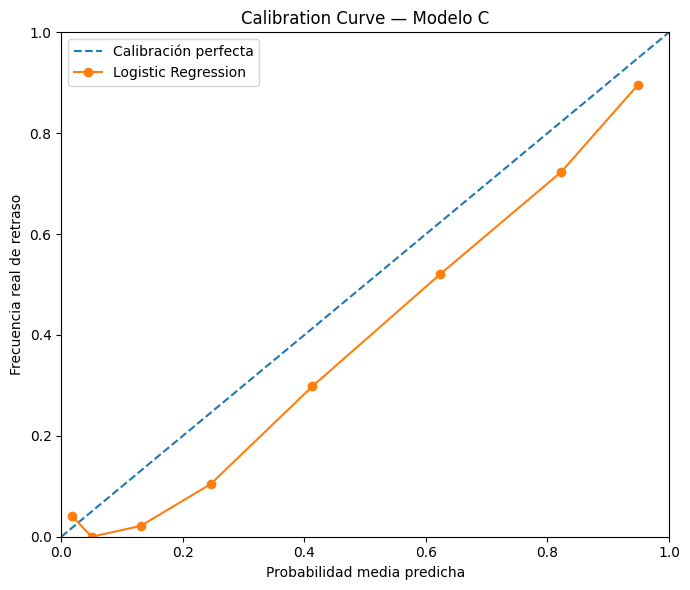

In [20]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

ax.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

ax.set_title(
    "Calibration Curve — Modelo C"
)

ax.set_xlabel(
    "Probabilidad media predicha"
)

ax.set_ylabel(
    "Frecuencia real de retraso"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.tight_layout()
plt.show()

### Tabla de calibracion

In [21]:
calibration_table = pd.DataFrame({
    "mean_predicted_probability": (
        prob_pred
    ),

    "observed_late_rate": (
        prob_true
    ),
})

calibration_table[
    "calibration_error"
] = (
    calibration_table[
        "observed_late_rate"
    ]
    -
    calibration_table[
        "mean_predicted_probability"
    ]
)

calibration_table[
    "absolute_calibration_error"
] = (
    calibration_table[
        "calibration_error"
    ]
    .abs()
)

calibration_table

,mean_predicted_probability,observed_late_rate,calibration_error,absolute_calibration_error
0,0.017205,0.041667,0.024462,0.024462
1,0.050086,0.000000,-0.050086,0.050086
2,0.130435,0.021277,-0.109158,0.109158
3,0.245610,0.104167,-0.141443,0.141443
4,0.412917,0.297872,-0.115045,0.115045
5,0.623766,0.520833,-0.102932,0.102932
6,0.822800,0.723404,-0.099396,0.099396
7,0.948895,0.895833,-0.053061,0.053061


### Distribucion de probabilidades

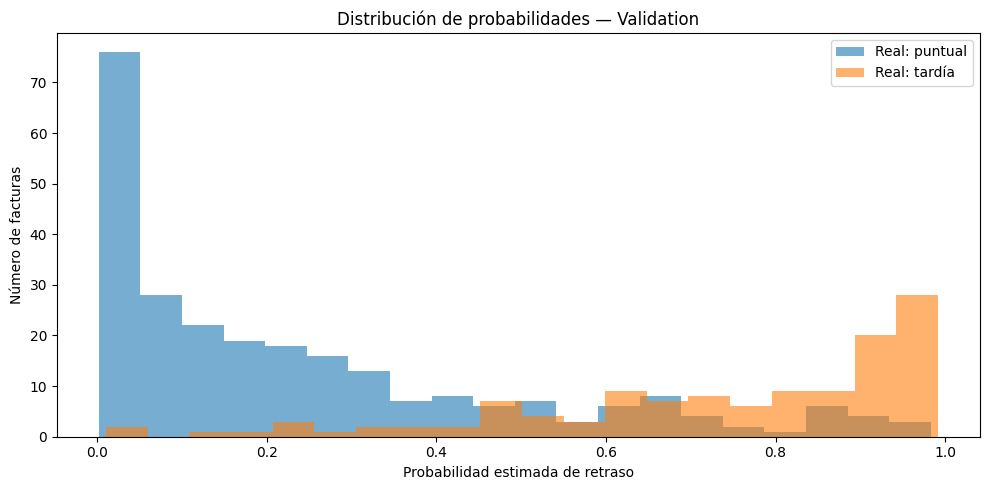

In [22]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.hist(
    y_validation_prob[
        y_validation.to_numpy() == 0
    ],
    bins=20,
    alpha=0.6,
    label="Real: puntual"
)

ax.hist(
    y_validation_prob[
        y_validation.to_numpy() == 1
    ],
    bins=20,
    alpha=0.6,
    label="Real: tardía"
)

ax.set_title(
    "Distribución de probabilidades — Validation"
)

ax.set_xlabel(
    "Probabilidad estimada de retraso"
)

ax.set_ylabel(
    "Número de facturas"
)

ax.legend()

plt.tight_layout()
plt.show()

### Riesgo media y tasa real

In [23]:
print(
    "Probabilidad media predicha:",
    f"{y_validation_prob.mean():.3%}"
)

print(
    "Tasa real de retraso:",
    f"{y_validation.mean():.3%}"
)

print(
    "Diferencia:",
    f"{(
        y_validation_prob.mean()
        - y_validation.mean()
    ):.3%}"
)

Probabilidad media predicha: 40.608%
Tasa real de retraso: 32.546%
Diferencia: 8.062%


### Posible efecto del cambio temporal de prevalencia

La sobreestimación observada debe interpretarse teniendo en cuenta que la distribución de la variable objetivo cambia con el tiempo.

La tasa de retraso es aproximadamente:

- 38,2 % en train;
- 32,5 % en validation.

La regresión logística se entrena durante un período con una prevalencia de retraso superior a la observada posteriormente.

Además, la probabilidad media estimada sobre validation es aproximadamente del 40,6 %, por encima de la tasa real observada del 32,5 %.

Por tanto, parte de la descalibración puede estar asociada a un cambio temporal en la prevalencia del evento.

Esto refuerza la necesidad de realizar la calibración utilizando un período temporal posterior al empleado para ajustar el modelo, reproduciendo de forma más realista cómo se actualizarían las probabilidades en producción.

### Expected Calibration Error (ECE)

In [24]:
calibration_eval = pd.DataFrame({
    "y_true": y_validation.to_numpy(),
    "y_prob": y_validation_prob,
})

calibration_eval["bin"] = pd.qcut(
    calibration_eval["y_prob"],
    q=8,
    duplicates="drop",
)

ece_table = (
    calibration_eval
    .groupby(
        "bin",
        observed=True
    )
    .agg(
        n=("y_true", "size"),
        mean_predicted_probability=(
            "y_prob",
            "mean"
        ),
        observed_late_rate=(
            "y_true",
            "mean"
        ),
    )
    .reset_index()
)

ece_table[
    "absolute_error"
] = (
    ece_table[
        "mean_predicted_probability"
    ]
    -
    ece_table[
        "observed_late_rate"
    ]
).abs()

ece = (
    (
        ece_table["n"]
        / len(calibration_eval)
    )
    * ece_table["absolute_error"]
).sum()

print(
    f"Expected Calibration Error: "
    f"{ece:.3%}"
)

ece_table

Expected Calibration Error: 8.678%


,bin,n,mean_predicted_probability,observed_late_rate,absolute_error
0,"(0.00089, 0.0313]",48,0.017205,0.041667,0.024462
1,"(0.0313, 0.0857]",48,0.050086,0.000000,0.050086
2,"(0.0857, 0.178]",47,0.130435,0.021277,0.109158
3,"(0.178, 0.324]",48,0.245610,0.104167,0.141443
4,"(0.324, 0.516]",47,0.412917,0.297872,0.115045
5,"(0.516, 0.7]",48,0.623766,0.520833,0.102932
6,"(0.7, 0.904]",47,0.822800,0.723404,0.099396
7,"(0.904, 0.992]",48,0.948895,0.895833,0.053061


## Conclusiones de la calibración original

La regresión logística mantiene una elevada capacidad de discriminación sobre validation:

- ROC-AUC = 0,904;
- PR-AUC = 0,802.

Sin embargo, el análisis probabilístico muestra una tendencia sistemática a sobreestimar el riesgo de retraso.

La probabilidad media predicha es aproximadamente:

`40,6 %`

mientras que la tasa real de retraso observada en validation es:

`32,5 %`

Esto representa una sobreestimación media cercana a 8 puntos porcentuales.

## Reliability curve

La reliability curve confirma este patrón.

En la mayoría de los intervalos de probabilidad, la frecuencia real de retraso se encuentra por debajo de la probabilidad estimada por el modelo.

Por ejemplo:

- riesgo predicho ≈ 24,6 % → retraso real ≈ 10,4 %;
- riesgo predicho ≈ 41,3 % → retraso real ≈ 29,8 %;
- riesgo predicho ≈ 62,4 % → retraso real ≈ 52,1 %;
- riesgo predicho ≈ 82,3 % → retraso real ≈ 72,3 %;
- riesgo predicho ≈ 94,9 % → retraso real ≈ 89,6 %.

Por tanto, el modelo diferencia correctamente las facturas de mayor y menor riesgo, pero tiende a producir probabilidades demasiado elevadas.

## Expected Calibration Error

Utilizando 8 bins construidos mediante cuantiles se obtiene aproximadamente:

`ECE = 8,68 %`

Esto significa que la diferencia absoluta media ponderada entre la probabilidad predicha y la frecuencia real observada es cercana a 8,7 puntos porcentuales.

El ECE debe interpretarse junto con la reliability curve, ya que su valor depende del número y método de construcción de los bins.

## Brier Score y Log Loss

La regresión logística obtiene aproximadamente:

- Brier Score = 0,122;
- Log Loss = 0,396.

Estos valores son considerablemente mejores que los obtenidos por un modelo ingenuo que asigna a todas las facturas una probabilidad constante basada en la prevalencia observada en train.

Esto confirma que las probabilidades contienen información predictiva útil.

Sin embargo, Brier Score y Log Loss no miden exclusivamente calibración. También dependen de la capacidad discriminativa del modelo, por lo que no sustituyen el análisis mediante reliability curve.

## Cambio temporal de prevalencia

La tasa de retraso disminuye entre los períodos utilizados:

- train ≈ 38,2 %;
- validation ≈ 32,5 %.

El modelo se ha entrenado en un período con una frecuencia de retrasos superior a la observada posteriormente.

Este cambio temporal puede explicar parte de la tendencia a sobreestimar el riesgo sobre validation.

Por tanto, la descalibración observada puede interpretarse parcialmente como una consecuencia del cambio de distribución temporal ya identificado durante el EDA y el modelado.

## Decisión

Se considera justificado evaluar una fase de recalibración.

El objetivo no será mejorar ROC-AUC o PR-AUC, ya que la capacidad de ranking del modelo es elevada.

La finalidad será corregir la escala probabilística para que valores como:

`riesgo de retraso = 0.70`

se aproximen mejor a la frecuencia real observada de retrasos en facturas con un riesgo similar.

La calibración deberá respetar nuevamente el orden temporal.

El modelo base se entrenará utilizando un período antiguo y el calibrador se ajustará utilizando un período posterior pero todavía contenido dentro de train.

Validation permanecerá completamente independiente para evaluar si la calibración realmente mejora.

El conjunto de test continuará reservado.

## 5. Recalibración temporal de probabilidades

La calibración no puede ajustarse utilizando las mismas observaciones empleadas para entrenar el clasificador.

Si se utilizasen las probabilidades obtenidas sobre train para ajustar posteriormente el calibrador, este aprendería sobre predicciones generadas por un modelo que ya había visto esas mismas observaciones.

Para evitarlo, el conjunto de train original se dividirá temporalmente en dos partes:

1. **model_train**
   - período más antiguo;
   - utilizado para entrenar la regresión logística.

2. **calibration_train**
   - período posterior dentro del antiguo train;
   - utilizado exclusivamente para ajustar el calibrador.

El conjunto de validation permanecerá completamente independiente y servirá para comprobar si la calibración mejora realmente las probabilidades sobre un período futuro.

La estructura será:

`model_train → calibration_train → validation → test`

El conjunto de test continuará completamente reservado.

## Métodos a comparar

Se evaluarán dos estrategias:

### Sigmoid / Platt scaling

Ajusta una transformación logística sobre los scores generados por el clasificador base.

Es un método relativamente conservador y requiere pocos parámetros, por lo que resulta adecuado cuando el conjunto disponible para calibración es limitado.

### Isotonic Regression

Aprende una función monótona no lineal entre score y probabilidad observada.

Tiene mayor flexibilidad, pero también mayor riesgo de sobreajuste cuando el conjunto de calibración es pequeño.

Por tanto, Isotonic se utilizará como comparación y no se asumirá inicialmente que una mayor flexibilidad implica una mejor calibración.

### Crear split interno dentro de train

In [25]:
train_unique_dates = np.sort(
    train_df["invoice_date"]
    .dropna()
    .unique()
)

calibration_cut_index = int(
    len(train_unique_dates) * 0.80
)

calibration_cutoff = (
    train_unique_dates[
        calibration_cut_index
    ]
)

print(
    "Calibration cutoff:",
    pd.Timestamp(
        calibration_cutoff
    ).date()
)

model_train_df = train_df[
    train_df["invoice_date"]
    < calibration_cutoff
].copy()

calibration_train_df = train_df[
    train_df["invoice_date"]
    >= calibration_cutoff
].copy()

Calibration cutoff: 2013-01-28


### Compobar nuevo split

In [26]:
calibration_split_summary = []

for name, subset in {
    "model_train": model_train_df,
    "calibration_train": calibration_train_df,
    "validation": validation_df,
}.items():

    calibration_split_summary.append({
        "dataset": name,

        "rows": len(subset),

        "start_date": (
            subset["invoice_date"]
            .min()
        ),

        "end_date": (
            subset["invoice_date"]
            .max()
        ),

        "positive_cases": (
            subset["late_payment"]
            .sum()
        ),

        "positive_rate": (
            subset["late_payment"]
            .mean()
        ),
    })

calibration_split_summary = pd.DataFrame(
    calibration_split_summary
)

display(calibration_split_summary)

assert (
    model_train_df["invoice_date"].max()
    <
    calibration_train_df["invoice_date"].min()
)

assert (
    calibration_train_df["invoice_date"].max()
    <
    validation_df["invoice_date"].min()
)

print(
    "✓ Split temporal de calibración correcto."
)

,dataset,rows,start_date,end_date,positive_cases,positive_rate
0,model_train,1377,2012-01-03,2013-01-27,533,0.387073
1,calibration_train,342,2013-01-28,2013-05-04,123,0.359649
2,validation,381,2013-05-05,2013-08-19,124,0.325459


✓ Split temporal de calibración correcto.


### `X` e `y`

In [27]:
X_model_train = (
    model_train_df[
        model_features
    ]
    .copy()
)

y_model_train = (
    model_train_df[
        "late_payment"
    ]
    .copy()
)

X_calibration_train = (
    calibration_train_df[
        model_features
    ]
    .copy()
)

y_calibration_train = (
    calibration_train_df[
        "late_payment"
    ]
    .copy()
)

print(
    "Model train:",
    X_model_train.shape
)

print(
    "Calibration train:",
    X_calibration_train.shape
)

print(
    "Validation:",
    X_validation.shape
)

Model train: (1377, 34)
Calibration train: (342, 34)
Validation: (381, 34)


### Comparación justa de la calibración

La regresión logística original del notebook fue entrenada utilizando todo el conjunto de train.

Para poder calibrar correctamente es necesario reservar una parte del antiguo train como conjunto independiente de calibración.

Esto significa que el clasificador base utilizado en esta sección dispondrá de menos observaciones para su entrenamiento.

Por tanto, se distinguirán dos referencias:

1. **Modelo original**
   - entrenado con todo train;
   - sirve como referencia del rendimiento alcanzado anteriormente.

2. **Modelo interno no calibrado**
   - entrenado únicamente con `model_train`;
   - sirve como comparación justa para Sigmoid e Isotonic, ya que los tres utilizan exactamente el mismo clasificador base.

La mejora provocada por la calibración deberá evaluarse principalmente comparando:

`internal uncalibrated vs sigmoid vs isotonic`

sobre el mismo conjunto de validation.

### Reconstruir modelo base interno

In [28]:
numeric_pipeline_internal = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

categorical_pipeline_internal = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

preprocessor_internal = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_internal,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline_internal,
            categorical_features,
        ),
    ]
)

internal_base_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_internal
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            )
        ),
    ]
)

### Entrenar modelo interno

In [29]:
internal_base_model.fit(
    X_model_train,
    y_model_train
)

print(
    "✓ Modelo interno entrenado."
)

✓ Modelo interno entrenado.


### Scores y probabilidades

In [30]:
internal_validation_prob = (
    internal_base_model
    .predict_proba(
        X_validation
    )[:, 1]
)

calibration_scores = (
    internal_base_model
    .decision_function(
        X_calibration_train
    )
)

validation_scores = (
    internal_base_model
    .decision_function(
        X_validation
    )
)

pd.DataFrame({
    "calibration_score": (
        calibration_scores
    )
}).describe()

,calibration_score
count,342.000000
mean,-0.980506
std,2.527441
min,-7.295349
25%,-2.564927
50%,-1.125755
75%,0.754588
max,4.771982


## 6. Sigmoid calibration / Platt scaling

Platt scaling aprende una transformación logística entre el score producido por el clasificador base y la probabilidad observada del evento.

Conceptualmente:

`score original → nueva función logística → probabilidad calibrada`

El método aprende únicamente una pendiente y un intercepto.

Por este motivo tiene poca flexibilidad y menor riesgo de sobreajuste que métodos no paramétricos.

Resulta especialmente adecuado como primera estrategia cuando el conjunto disponible para calibración es relativamente pequeño.

La capacidad de ranking del modelo debería permanecer prácticamente inalterada porque la transformación es monótona.

### Entrenar calibrador Sigmoid

In [31]:
sigmoid_calibrator = LogisticRegression(
    C=1e6,
    max_iter=1000,
    random_state=42,
)

calibration_scores_2d = (
    calibration_scores
    .reshape(-1, 1)
)

sigmoid_calibrator.fit(
    calibration_scores_2d,
    y_calibration_train
)

print(
    "✓ Sigmoid calibrator entrenado."
)

✓ Sigmoid calibrator entrenado.


### Probabilidades de Sigmoid en validation

In [32]:
validation_scores_2d = (
    validation_scores
    .reshape(-1, 1)
)

sigmoid_validation_prob = (
    sigmoid_calibrator
    .predict_proba(
        validation_scores_2d
    )[:, 1]
)

pd.Series(
    sigmoid_validation_prob
).describe()

count    381.000000
mean       0.417129
std        0.314474
min        0.006741
25%        0.132069
50%        0.354825
75%        0.683896
max        0.976196
dtype: float64

## 7. Isotonic Regression

Isotonic Regression aprende una función monótona no lineal entre el score del modelo y la frecuencia observada del evento.

A diferencia de Platt scaling, no impone una forma logística determinada.

Esto permite corregir relaciones de calibración más complejas.

Sin embargo, su mayor flexibilidad implica también mayor riesgo de sobreajuste cuando el conjunto utilizado para calibrar contiene pocas observaciones.

Por este motivo se utilizará como método comparativo.

Su selección solo se justificará si mejora de forma clara y estable las métricas probabilísticas sobre validation.

### Crear y entrenar Isotonic

In [33]:
from sklearn.isotonic import (
    IsotonicRegression
)

isotonic_calibrator = (
    IsotonicRegression(
        y_min=0.0,
        y_max=1.0,
        out_of_bounds="clip",
    )
)

isotonic_calibrator.fit(
    calibration_scores,
    y_calibration_train
)

print(
    "✓ Isotonic calibrator entrenado."
)

✓ Isotonic calibrator entrenado.


### Probabilidades Isotonic

In [34]:
isotonic_validation_prob = (
    isotonic_calibrator
    .predict(
        validation_scores
    )
)

pd.Series(
    isotonic_validation_prob
).describe()

count    381.000000
mean       0.414366
std        0.327863
min        0.000000
25%        0.144390
50%        0.395833
75%        0.617748
max        1.000000
dtype: float64

### Funcion para ECE

In [35]:
def calculate_ece(
    y_true,
    y_prob,
    n_bins=8
):
    calibration_data = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob),
    })

    calibration_data["bin"] = pd.qcut(
        calibration_data["y_prob"],
        q=n_bins,
        duplicates="drop",
    )

    table = (
        calibration_data
        .groupby(
            "bin",
            observed=True
        )
        .agg(
            n=("y_true", "size"),

            mean_predicted_probability=(
                "y_prob",
                "mean"
            ),

            observed_late_rate=(
                "y_true",
                "mean"
            ),
        )
        .reset_index()
    )

    table[
        "absolute_error"
    ] = (
        table[
            "mean_predicted_probability"
        ]
        -
        table[
            "observed_late_rate"
        ]
    ).abs()

    ece = (
        (
            table["n"]
            / len(calibration_data)
        )
        *
        table["absolute_error"]
    ).sum()

    return ece

### Funcion evaluacion probabilistica

In [36]:
def evaluate_probabilities(
    y_true,
    y_prob,
    model_name
):
    return {
        "model": model_name,

        "brier_score": (
            brier_score_loss(
                y_true,
                y_prob
            )
        ),

        "log_loss": (
            log_loss(
                y_true,
                np.column_stack([
                    1 - y_prob,
                    y_prob,
                ])
            )
        ),

        "ece": (
            calculate_ece(
                y_true,
                y_prob,
                n_bins=8
            )
        ),

        "roc_auc": (
            roc_auc_score(
                y_true,
                y_prob
            )
        ),

        "pr_auc": (
            average_precision_score(
                y_true,
                y_prob
            )
        ),

        "mean_probability": (
            np.mean(
                y_prob
            )
        ),

        "observed_rate": (
            np.mean(
                y_true
            )
        ),
    }

### Comparacion justa de calibracion

In [37]:
calibration_results = pd.DataFrame([
    evaluate_probabilities(
        y_validation,
        internal_validation_prob,
        "Internal uncalibrated"
    ),

    evaluate_probabilities(
        y_validation,
        sigmoid_validation_prob,
        "Sigmoid"
    ),

    evaluate_probabilities(
        y_validation,
        isotonic_validation_prob,
        "Isotonic"
    ),
])

calibration_results = (
    calibration_results
    .sort_values(
        "brier_score"
    )
    .reset_index(drop=True)
)

calibration_results

,model,brier_score,log_loss,ece,roc_auc,pr_auc,mean_probability,observed_rate
0,Sigmoid,0.127570,0.408926,0.091670,0.900213,0.792484,0.417129,0.325459
1,Internal uncalibrated,0.134345,0.437042,0.118681,0.900213,0.792484,0.442641,0.325459
2,Isotonic,0.137810,0.605729,0.111551,0.893624,0.757097,0.414366,0.325459


Esta comparación permite aislar el efecto específico de la calibración, ya que los tres métodos parten del mismo clasificador base.

Sin embargo, para seleccionar el sistema que finalmente se utilizará también será necesario comparar estas alternativas con el Modelo C original entrenado utilizando todo el conjunto de train.

Aunque las condiciones de entrenamiento del clasificador base no sean idénticas, ambas estrategias utilizan exclusivamente información anterior a validation y pueden compararse sobre ese período como sistemas predictivos completos.

La estrategia final se seleccionará atendiendo a su rendimiento sobre validation y a su complejidad.

### Añadimos modelo original como referencia

In [38]:
original_reference = pd.DataFrame([
    evaluate_probabilities(
        y_validation,
        y_validation_prob,
        "Original full-train model"
    )
])

final_calibration_comparison = pd.concat(
    [
        original_reference,
        calibration_results,
    ],
    ignore_index=True
)

final_calibration_comparison = (
    final_calibration_comparison[
        [
            "model",
            "brier_score",
            "log_loss",
            "ece",
            "roc_auc",
            "pr_auc",
            "mean_probability",
            "observed_rate",
        ]
    ]
    .sort_values(
        "brier_score"
    )
    .reset_index(drop=True)
)

final_calibration_comparison

,model,brier_score,log_loss,ece,roc_auc,pr_auc,mean_probability,observed_rate
0,Original full-train model,0.121851,0.396029,0.086783,0.904387,0.801798,0.406079,0.325459
1,Sigmoid,0.127570,0.408926,0.091670,0.900213,0.792484,0.417129,0.325459
2,Internal uncalibrated,0.134345,0.437042,0.118681,0.900213,0.792484,0.442641,0.325459
3,Isotonic,0.137810,0.605729,0.111551,0.893624,0.757097,0.414366,0.325459


## Criterio para seleccionar calibración

La comparación principal se realizará entre:

- `Internal uncalibrated`;
- `Sigmoid`;
- `Isotonic`.

Los tres utilizan exactamente el mismo clasificador base entrenado sobre `model_train`.

Por tanto, cualquier diferencia entre ellos puede atribuirse al proceso de calibración.

Se considerarán especialmente:

### Brier Score

Menor es mejor.

### Log Loss

Menor es mejor.

### ECE

Menor indica mayor proximidad entre probabilidades predichas y frecuencias observadas en los bins utilizados.

### ROC-AUC y PR-AUC

La calibración no debería deteriorar de forma relevante la capacidad de ranking.

Sigmoid debería mantener prácticamente el mismo ranking porque aplica una transformación monótona.

Isotonic puede introducir empates y pequeñas modificaciones del ranking.

## Modelo original

El modelo entrenado con todo train se conservará como referencia adicional.

No se comparará directamente con los calibradores como si las condiciones fuesen idénticas, ya que el modelo original dispone de más observaciones para entrenar el clasificador base.

La decisión sobre la estrategia final deberá equilibrar:

- calidad de calibración;
- capacidad discriminativa;
- cantidad de datos disponibles para entrenar el clasificador.

### Reliability curves comparadas

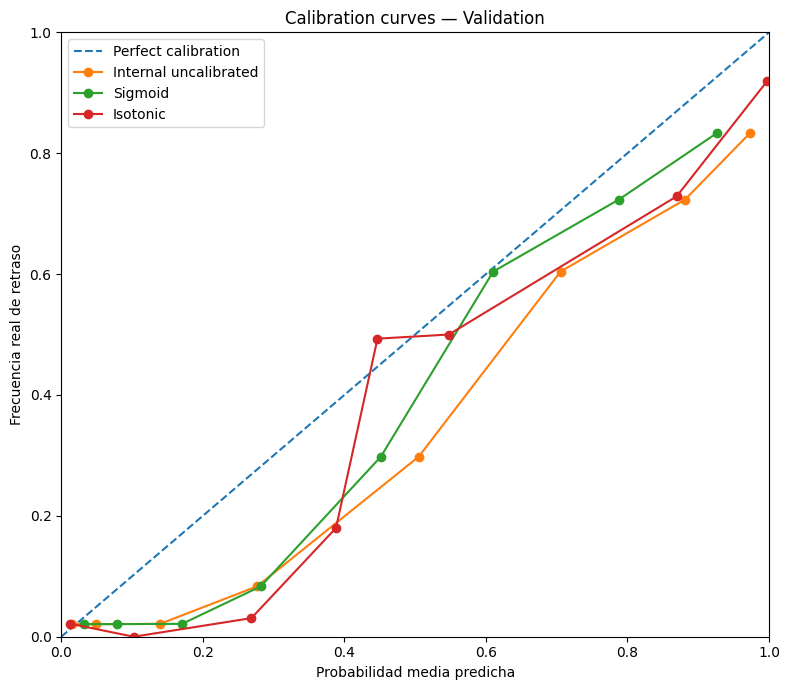

In [39]:
calibration_methods = {
    "Internal uncalibrated": (
        internal_validation_prob
    ),

    "Sigmoid": (
        sigmoid_validation_prob
    ),

    "Isotonic": (
        isotonic_validation_prob
    ),
}

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

for name, probabilities in (
    calibration_methods.items()
):

    prob_true_method, prob_pred_method = (
        calibration_curve(
            y_validation,
            probabilities,
            n_bins=8,
            strategy="quantile",
        )
    )

    ax.plot(
        prob_pred_method,
        prob_true_method,
        marker="o",
        label=name,
    )

ax.set_title(
    "Calibration curves — Validation"
)

ax.set_xlabel(
    "Probabilidad media predicha"
)

ax.set_ylabel(
    "Frecuencia real de retraso"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.tight_layout()
plt.show()

### Comparar Brier

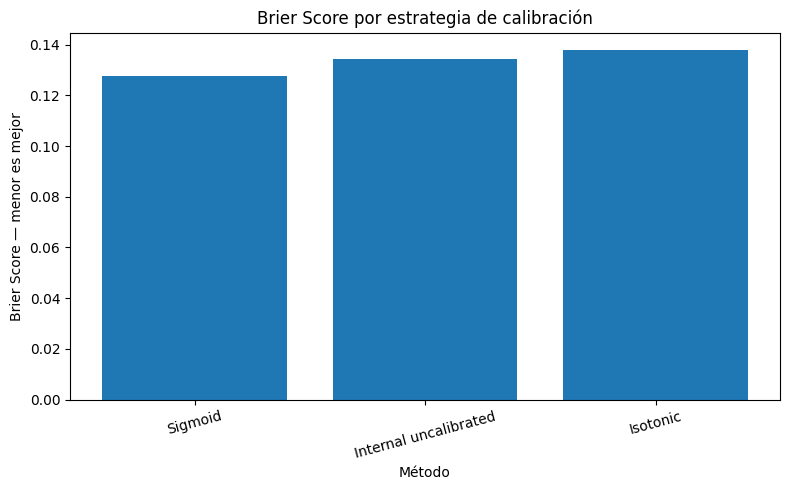

In [40]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    calibration_results[
        "model"
    ],
    calibration_results[
        "brier_score"
    ]
)

ax.set_title(
    "Brier Score por estrategia de calibración"
)

ax.set_ylabel(
    "Brier Score — menor es mejor"
)

ax.set_xlabel(
    "Método"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()

### Comparar ECE

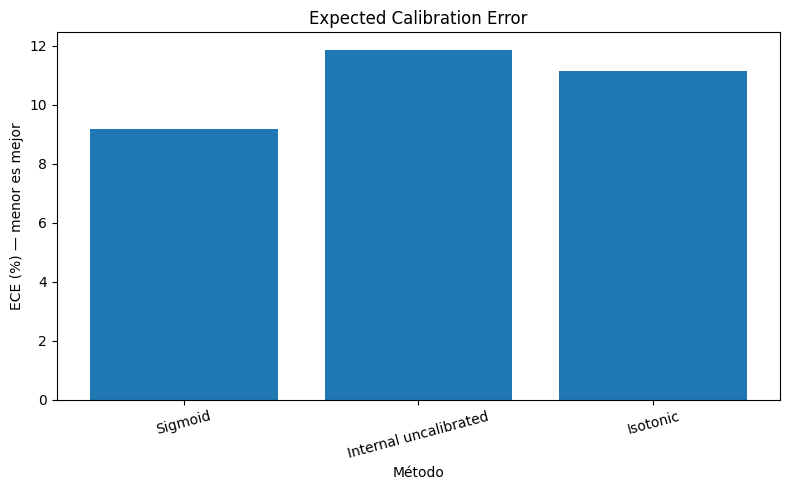

In [41]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    calibration_results[
        "model"
    ],
    calibration_results[
        "ece"
    ] * 100
)

ax.set_title(
    "Expected Calibration Error"
)

ax.set_ylabel(
    "ECE (%) — menor es mejor"
)

ax.set_xlabel(
    "Método"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()

### Comparar riesgo medio

In [42]:
mean_probability_comparison = (
    calibration_results[
        [
            "model",
            "mean_probability",
            "observed_rate",
        ]
    ]
    .copy()
)

mean_probability_comparison[
    "difference"
] = (
    mean_probability_comparison[
        "mean_probability"
    ]
    -
    mean_probability_comparison[
        "observed_rate"
    ]
)

mean_probability_comparison

,model,mean_probability,observed_rate,difference
0,Sigmoid,0.417129,0.325459,0.091670
1,Internal uncalibrated,0.442641,0.325459,0.117182
2,Isotonic,0.414366,0.325459,0.088907


### Original vs Sigmoid

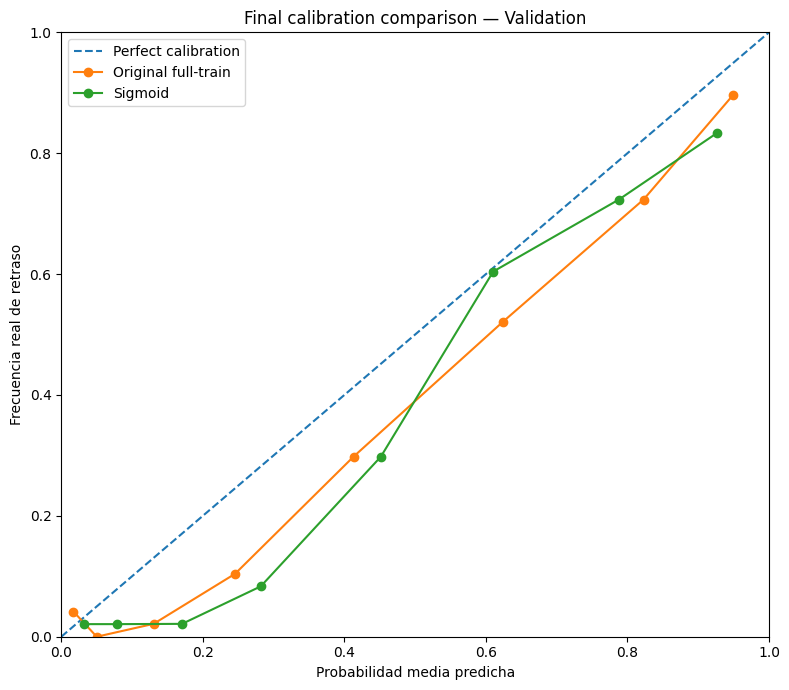

In [43]:
final_curve_methods = {
    "Original full-train": y_validation_prob,
    "Sigmoid": sigmoid_validation_prob,
}

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

for name, probabilities in final_curve_methods.items():

    prob_true_method, prob_pred_method = calibration_curve(
        y_validation,
        probabilities,
        n_bins=8,
        strategy="quantile",
    )

    ax.plot(
        prob_pred_method,
        prob_true_method,
        marker="o",
        label=name,
    )

ax.set_title(
    "Final calibration comparison — Validation"
)

ax.set_xlabel(
    "Probabilidad media predicha"
)

ax.set_ylabel(
    "Frecuencia real de retraso"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

## Decisión sobre la calibración

La calibración mediante Sigmoid mejora claramente las probabilidades respecto al clasificador interno no calibrado entrenado únicamente con `model_train`.

En esa comparación:

- Brier Score mejora de aproximadamente 0,134 a 0,128;
- Log Loss mejora de aproximadamente 0,437 a 0,409;
- ECE mejora de aproximadamente 11,9 % a 9,2 %;
- ROC-AUC y PR-AUC permanecen prácticamente invariantes.

Esto confirma que Platt scaling es capaz de corregir parcialmente la escala probabilística del clasificador base.

Isotonic Regression no obtiene un resultado satisfactorio:

- empeora Brier Score;
- empeora considerablemente Log Loss;
- reduce ROC-AUC;
- reduce PR-AUC.

Su mayor flexibilidad no resulta adecuada para el tamaño del conjunto de calibración disponible y se descarta.

### Comparación con el Modelo C original

La estrategia calibrada mediante Sigmoid tampoco consigue superar al Modelo C original entrenado utilizando todo el conjunto de train.

El modelo original obtiene aproximadamente:

- Brier Score = 0,122;
- Log Loss = 0,396;
- ECE = 8,68 %;
- ROC-AUC = 0,904;
- PR-AUC = 0,802.

Sigmoid obtiene aproximadamente:

- Brier Score = 0,128;
- Log Loss = 0,409;
- ECE = 9,17 %;
- ROC-AUC = 0,900;
- PR-AUC = 0,792.

Por tanto, la pérdida de información provocada por reservar una parte del histórico para calibrar el modelo base no se compensa con la mejora obtenida mediante recalibración.

### Decisión

Se mantiene como estrategia final la **regresión logística Modelo C original sin calibración externa**.

La recalibración mediante Sigmoid demuestra que existe cierta capacidad para corregir las probabilidades, pero no produce una mejora del sistema completo sobre validation.

Isotonic queda descartado.

El threshold operativo provisional de `0.40`, seleccionado anteriormente utilizando las probabilidades originales de la regresión logística, se mantiene sin modificaciones.

El conjunto de test continúa completamente reservado.

# Conclusiones finales de calibración

El análisis de calibración confirma que la regresión logística presenta una elevada capacidad de discriminación, pero sus probabilidades muestran una tendencia moderada a sobreestimar el riesgo de retraso sobre períodos posteriores.

El Modelo C original obtiene sobre validation:

- ROC-AUC = 0,904;
- PR-AUC = 0,802;
- Brier Score = 0,122;
- Log Loss = 0,396;
- ECE ≈ 8,68 %.

La probabilidad media estimada es aproximadamente del 40,6 %, mientras que la tasa real observada es del 32,5 %.

## Recalibración mediante Sigmoid

Se ha construido una estrategia temporal independiente dividiendo el antiguo train en:

- `model_train`, utilizado para entrenar la regresión logística;
- `calibration_train`, utilizado posteriormente para ajustar el calibrador.

Sigmoid / Platt scaling mejora claramente la calibración respecto al clasificador interno no calibrado.

Sin embargo, la estrategia completa no consigue superar al Modelo C original entrenado utilizando todo el histórico disponible.

Sigmoid obtiene aproximadamente:

- Brier Score = 0,128;
- Log Loss = 0,409;
- ECE = 9,17 %;
- ROC-AUC = 0,900;
- PR-AUC = 0,792.

Estos resultados son ligeramente inferiores a los obtenidos por el modelo original.

## Isotonic Regression

Isotonic Regression presenta un rendimiento inferior:

- Brier Score = 0,138;
- Log Loss = 0,606;
- ECE = 11,16 %;
- ROC-AUC = 0,894;
- PR-AUC = 0,757.

La mayor flexibilidad del método no resulta adecuada para el reducido conjunto de calibración disponible y produce una pérdida de generalización.

Por este motivo queda descartado.

## Efecto del cambio temporal

La tasa de retraso disminuye progresivamente:

- model_train ≈ 38,7 %;
- calibration_train ≈ 36,0 %;
- validation ≈ 32,5 %.

Esta evolución indica que parte de la sobreestimación de probabilidades está relacionada con un cambio temporal de prevalencia.

Un calibrador ajustado utilizando datos históricos puede corregir parte de la escala probabilística, pero no puede anticipar completamente un nuevo cambio de prevalencia en períodos futuros.

Por tanto, la calibración deberá considerarse un proceso potencialmente dinámico en una futura aplicación real.

## Selección final

No se aplicará una calibración externa al modelo final.

Se mantiene:

**Logistic Regression — Modelo C**

entrenada utilizando todo el conjunto de train.

El threshold operativo provisional continúa siendo:

`threshold = 0.40`

La probabilidad producida por el modelo podrá utilizarse como scoring continuo de riesgo, aunque deberá evitarse interpretar cada valor como una probabilidad perfectamente calibrada.

En una aplicación real sería recomendable monitorizar periódicamente:

- tasa real de retraso;
- Brier Score;
- calibration curve;
- drift temporal;
- diferencia entre riesgo medio estimado y prevalencia observada.

El conjunto de test continúa completamente reservado.

La estrategia de modelo, features y calibración queda congelada.

El siguiente paso será realizar una única evaluación final sobre el conjunto de test temporal.